In [6]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## A-deck forcast loss 

Here we use, the A-deck containing the huricane forcast, to estimate past and forcast expected future loss. 

In [7]:
# Import functions from src directory (src is ../src)
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')

from download_TC_data import download_storm_forecast, extract_gzip
from preprocess_TC_data import clean_track_data, clean_track_data2
from utils import track_interpolation, cyclone_velocity, cyclone_bearing, extract_past_trajectory, extract_future_trajectory, prepare_track_data
from visualization import make_trajectory_animation, plot_trajectory
from generate_exposure import generate_synthetic_portfolio
from wind_fields import get_heuristic_rmw
from loss import portfolio_damage_model, impact_tc_A_deck

In [8]:
# Download and extract storm forecast data
forecast_path = extract_gzip(download_storm_forecast(2018, 'al', '14', deck='a'))

Year is 2018. Checking ARCHIVE source...


91it [00:00, 141.96it/s]


Downloaded to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat


In [9]:
# Load and clean the data 
df_forcast = clean_track_data2(forecast_path, is_best_track=False)
df_OFCL = df_forcast[df_forcast['TECH'] == 'OFCL'].copy()


/Users/wirths/Documents/Private/NatCat/notebooks/../src/preprocess_TC_data.py:67: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, names=col_names, sep=",", skipinitialspace=True, on_bad_lines='warn')


Looking for TECH column with value 'OFCL'


In [10]:
# Helper functions to extract past (model initialization) and future (forcasted) trajectories
def extract_past_trajectory(df,timestamp, tech='OFCL'):
    df_ptrac = df[df['TECH'] == tech].copy()
    df_ptrac = df_ptrac[df_ptrac['timestamp'] <= timestamp]
    df_ptrac = df_ptrac[df_ptrac['tau'] == 0]

    # Remove duplicates
    df_ptrac = df_ptrac.drop_duplicates(subset=['timestamp'], keep='last')
    
    return df_ptrac

def extract_future_trajectory(df,timestamp, tech='OFCL'):
    df_ftrac = df[df['TECH'] == tech].copy()
    df_ftrac = df_ftrac[df_ftrac['timestamp'] == timestamp]
    #df_ftrac = df_ftrac[df_ftrac['tau'] != 0]

    # Remove duplicates
    df_ftrac = df_ftrac.drop_duplicates(subset=['tau'], keep='last')

    # Add tau to timestamp to get future timestamps
    df_ftrac['timestamp'] = df_ftrac['timestamp'] + pd.to_timedelta(df_ftrac['tau'], unit='h')
    
    return df_ftrac

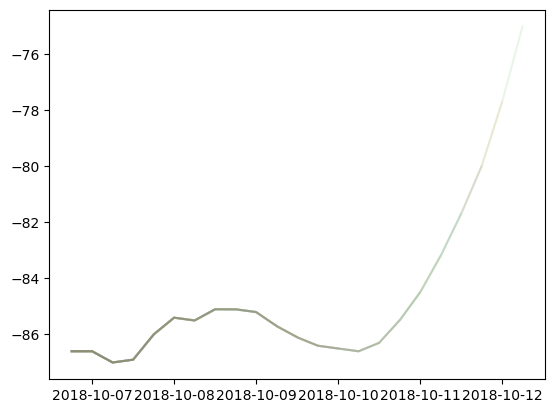

In [53]:
import matplotlib.pyplot as plt

for timestamp in df_OFCL['timestamp'].unique():
    time_frame = prepare_track_data(df_forcast,timestamp,"OFCL")
    #time_frame2 = prepare_track_data(df_forcast,'2018-10-12 00:00:00',"OFCL")

    plt.plot(time_frame[0].time, time_frame[0].longitude, alpha=0.1)
    #plt.plot(time_frame2[0].max_wind_speed_kt)
plt.show()

In [43]:
time_frame

(                    time   latitude  longitude  max_wind_speed_kt  \
 0    2018-10-06 18:00:00  17.800000   -86.6000          25.000000   
 1    2018-10-06 18:05:00  17.809722   -86.6000          25.000000   
 2    2018-10-06 18:10:00  17.819444   -86.6000          25.000000   
 3    2018-10-06 18:15:00  17.829167   -86.6000          25.000000   
 4    2018-10-06 18:20:00  17.838889   -86.6000          25.000000   
 ...                  ...        ...        ...                ...   
 1580 2018-10-12 05:40:00  37.255556   -75.1500          54.444444   
 1581 2018-10-12 05:45:00  37.266667   -75.1125          54.583333   
 1582 2018-10-12 05:50:00  37.277778   -75.0750          54.722222   
 1583 2018-10-12 05:55:00  37.288889   -75.0375          54.861111   
 1584 2018-10-12 06:00:00  37.300000   -75.0000          55.000000   
 
       radius_max_wind_nm  velocity_kt  bearing_deg  
 0              80.000000     7.004720     0.000000  
 1              80.000000     7.004720     0.00000

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


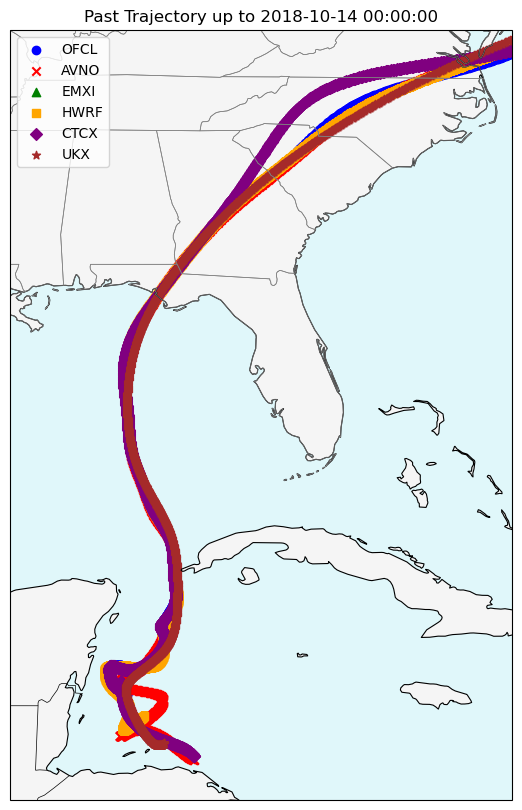

In [29]:
# We can now plot the trajectories of the past and the forcasted future 
_ = plot_trajectory(df_forcast, ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX'], '2018-10-14 00:00:00')

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


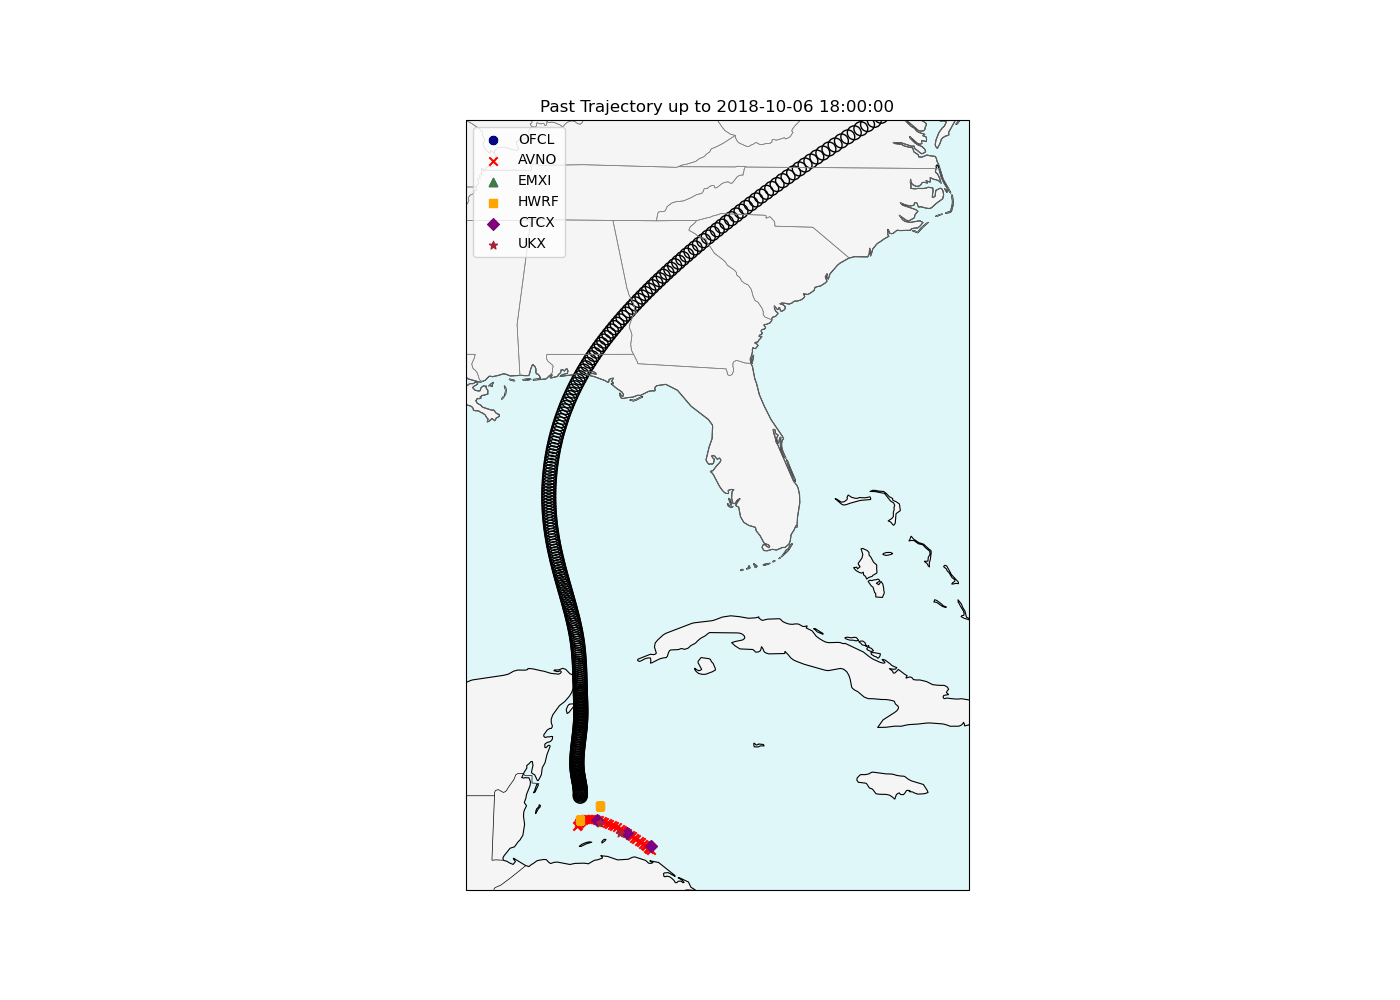

In [7]:
# Also as animation
_ = make_trajectory_animation(df_forcast, df_OFCL)

In [14]:
# We now prepare the track data for loss estimation

def prepare_track_data(df, timestamp, model, avail=1, past=True):
    if past:
        df_out = extract_past_trajectory(df, timestamp, tech=model)
    else: 
        df_out = extract_future_trajectory(df, timestamp, tech=model)

    df_out = get_heuristic_rmw(df_out)
    try:
        df_out = track_interpolation(df_out, time_step='30min', kind='cubic')
        # 'cubic' leads global smoothness but not local stability, thus small variations in the max data can ocure due to recalculation of the tracks
    except:
        avail = 0

    #Drop low wind speed columns
    #df_out = df_out[df_out['max_wind_speed_kt'] >= 40].reset_index(drop=True)
    # Add cyclone bearing and velocity
    df_out = cyclone_velocity(df_out)
    df_out = cyclone_bearing(df_out)

    return df_out, avail

def get_heuristic_rmw(df):
    df_fixed = df.copy()
    winds = df_fixed['max_wind_speed_kt'].fillna(0)
    storm_type = df_fixed['storm_type'] 


    # We do a simple windspeed to radius mapping: e.g. <35kt -> 80nm, <64kt -> 60nm, <96kt -> 40nm, <137kt -> 25nm, else 15nm
    conditions = [
        winds < 35,   
        winds < 64,   
        winds < 96,   
        winds < 137   
    ]

    choices = [
        80.0, 
        60.0,  
        40.0,  
        25.0   
    ]
    
    heuristic_rmw = np.select(conditions, choices, default=15.0)
    needs_fix_mask = (df_fixed['radius_max_wind_nm'].isna()) | (df_fixed['radius_max_wind_nm'] <= 0)

    df_fixed.loc[needs_fix_mask, 'radius_max_wind_nm'] = heuristic_rmw[needs_fix_mask]

    # We also aply a flat 1.5 scaling for extratropical cyclones
    ex_mask = df_fixed['storm_type'] == 'EX'
    df_fixed.loc[ex_mask, 'radius_max_wind_nm'] *= 1.5
        
    return df_fixed

def portfolio_damage_model(df_tc_track, housing_portfolio, asymmetry_factor=1.0):
    """Calculates the damage to a housing portfolio given a tropical cyclone track."""
    from wind_fields import max_wind_speeds_at_locations
    from vulnerbility import get_damage_ratio
    # Get lon lat touples for portfolio
    points = list(zip(housing_portfolio['latitude'], housing_portfolio['longitude']))
    max_wind_speeds = max_wind_speeds_at_locations(df_tc_track, points, asymmetry_factor=asymmetry_factor)
    
    
    # Compute damage ratios based on the maximum wind speeds
    damage_ratios = get_damage_ratio(max_wind_speeds)

    portfolio_damages = damage_ratios * housing_portfolio['tiv']
    
    # Append portfolio damages to housing_portfolio dataframe
    housing_portfolio = housing_portfolio.copy()
    housing_portfolio['damage_ratio'] = damage_ratios
    housing_portfolio['damage'] = portfolio_damages

    return housing_portfolio


# Loss model for forcast 

# Inputs: 
from numpy import extract


housing_portfolio = generate_synthetic_portfolio(num_locs=1000)

def impact_tc_A_deck(df_tc_A_deck, housing_portfolio,timestamp=None, trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX'], full_report=False):
    """Calculates impact of a tropical cyclone given its A-deck data and a housing portfolio.
    If timestamp is provided, only considers past data up to that timestamp and forecasts from that point onward.
    
    Inputs: 
    - df_tc_A_deck: DataFrame containing the A-deck data of the tropical cyclone. (Already precleaned track data e.g. from clean_track_data2)
    - housing_portfolio: DataFrame containing the housing portfolio data.
    - timestamp: Optional; if provided, only considers data up to this timestamp.
    - trusted_models: List of trusted forecast models to consider.
    
    Outputs:"""
    import pandas as pd
    if timestamp is None:
        # Use latest timestamp as timestamp
        timestamp = df_tc_A_deck['timestamp'].max()
    
    df_past_list = []
    df_future_list = []

    history_avail = np.ones(len(trusted_models))
    future_avail = np.ones(len(trusted_models))
    
    for i, model in enumerate(trusted_models):
        
        # Past trajectory (initialization data)
        df_past, history_avail[i] = prepare_track_data(df_tc_A_deck, timestamp, model, avail=history_avail[i], past=True)
        df_past_list.append(df_past)

        # Future trajectory (forecasted data)
        df_future, future_avail[i] = prepare_track_data(df_tc_A_deck, timestamp, model, avail=future_avail[i], past=False)
        df_future_list.append(df_future)

    #return df_past_list, df_future_list, history_avail, future_avail
    past_damages = []
    future_damages = []
    for idx, model in enumerate(trusted_models):
        if history_avail[idx] == 1:
            df_past = df_past_list[idx]
            portfolio_damage = portfolio_damage_model(df_past, housing_portfolio)
            past_damages.append(portfolio_damage)

    for idx, model in enumerate(trusted_models):
        if future_avail[idx] == 1:
            df_future = df_future_list[idx]
            portfolio_damage = portfolio_damage_model(df_future, housing_portfolio)
            future_damages.append(portfolio_damage)
    

    return past_damages, future_damages, history_avail, future_avail

In [15]:
# Calculate losses for all timestamps in the "trusted models"
trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']
index = df_OFCL['timestamp'].unique()
future_loss = pd.DataFrame(index=index, columns=trusted_models)
past_loss = pd.DataFrame(index=index, columns=trusted_models)
history_aware_future_loss = pd.DataFrame(index=index, columns=trusted_models)


for timestamp in df_OFCL['timestamp'].unique():
    past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp=timestamp)
    
    # Map past damages to their corresponding models
    past_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if history_avail[model_idx] == 1:
            past_damage_total = past_damages[past_idx]['damage'].sum()
            #print(f"Timestamp: {timestamp}, Model: {model}, Past Damage: {past_damage_total}")
            past_loss.loc[timestamp, model] = past_damage_total
            past_idx += 1

    # Map future damages to their corresponding models
    future_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if future_avail[model_idx] == 1:
            future_damage_total = future_damages[future_idx]['damage'].sum()
            future_loss.loc[timestamp, model] = future_damage_total
            future_idx += 1

    # Hisoty aware future loss estimation
    haw_future_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if future_avail[model_idx] == 1 and history_avail[model_idx] == 1:
            
            # find corresponding indices in the past/future lists
            p_idx = int(np.sum(history_avail[:model_idx+1]) - 1)
            f_idx = int(np.sum(future_avail[:model_idx+1]) - 1)

            # elementwise max between past and future damages per location, then sum
            combined_damage_total = pd.concat(
                [past_damages[p_idx]['damage'], future_damages[f_idx]['damage']],
                axis=1
            ).max(axis=1).sum()
            history_aware_future_loss.loc[timestamp, model] = combined_damage_total
            haw_future_idx += 1


/var/folders/wx/t338ck_s4qz_jg5cr9mg00hc0000gn/T/ipykernel_31261/1127489027.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cols = plt.cm.get_cmap('tab10', len(trusted_models))


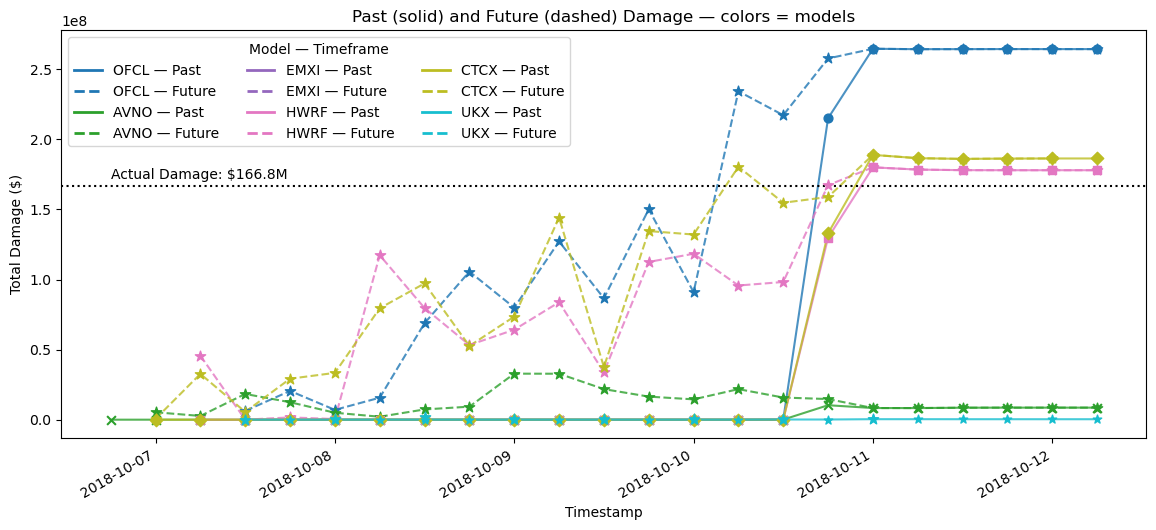

In [16]:
# Visualize the results: colored lines for each model (solid = past, dashed = future)
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,6))
cols = plt.cm.get_cmap('tab10', len(trusted_models))
markers = ['o','x','^','s','D','*']

# Plot colored lines for each model: solid = past, dashed = future.
for i, model in enumerate(trusted_models):
    color = cols(i)
    ax.plot(past_loss.index, past_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='-')
    #ax.plot(future_loss.index, future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    ax.scatter(past_loss.index, past_loss[model], color=color, marker=markers[i % len(markers)], s=40, zorder=3)
    #ax.scatter(future_loss.index, future_loss[model], color=color, marker='x', s=50, zorder=3)
    ax.plot(history_aware_future_loss.index, history_aware_future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    ax.scatter(history_aware_future_loss.index, history_aware_future_loss[model], color=color, marker='*', s=60, zorder=3)

    # ax.plot(past_loss.index, past_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='-')
    # ax.plot(future_loss.index, past_loss[model]+future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    # ax.scatter(past_loss.index, past_loss[model], color=color, marker=markers[i % len(markers)], s=40, zorder=3)
    # ax.scatter(future_loss.index, past_loss[model]+future_loss[model], color=color, marker='x', s=50, zorder=3)

# Single aggregated legend: each entry shows model color + linestyle for past/future
handles = []
labels = []
for i, model in enumerate(trusted_models):
    color = cols(i)
    handles.append(Line2D([0],[0], color=color, lw=2, linestyle='-'))
    labels.append(f"{model} — Past")
    handles.append(Line2D([0],[0], color=color, lw=2, linestyle='--'))
    labels.append(f"{model} — Future")

ax.legend(handles, labels, title='Model — Timeframe', ncol=3, loc='upper left', bbox_to_anchor=(0,1))
ax.axhline(y=166832860.59, color='k', linestyle=':', label='Actual Damage')
ax.text(future_loss.index[0], 170000000, 'Actual Damage: $166.8M', color='k', fontsize=10, va='bottom', ha='left')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Damage ($)')
ax.set_title('Past (solid) and Future (dashed) Damage — colors = models')
fig.autofmt_xdate()
plt.show()